
Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


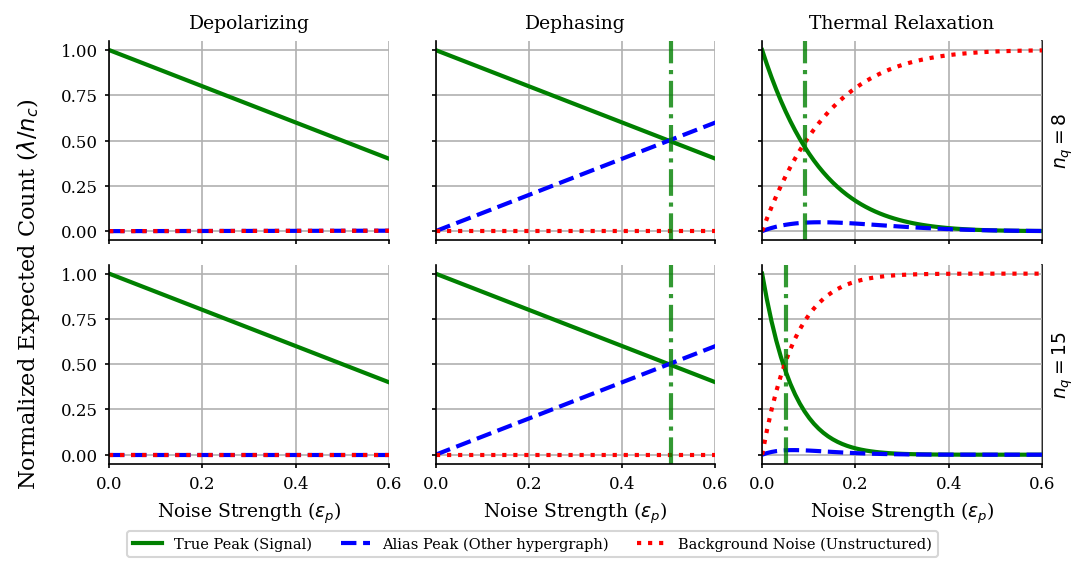

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Match manuscript/fig1 plot styling.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "figures_notebooks" else Path.cwd()
plt.style.use(str(REPO_ROOT / "figures_notebooks" / "single_column.mplstyle"))

# 1. Setup the parameters
n_values = [8, 15]
eps_p = np.linspace(0, 1, 100)  # Noise strength from 0 to 1


def channel_curves(n):
    """Return (true, ghost, background) for each channel at fixed n_q."""
    num_bins = 2 ** n

    # Depolarizing (scattered noise).
    depol_true = 1 - eps_p
    depol_ghost = eps_p / (num_bins - 1)
    depol_bg = eps_p / (num_bins - 1)

    # Dephasing (structured lies).
    dephase_true = 1 - eps_p
    dephase_ghost = eps_p
    dephase_bg = np.zeros_like(eps_p)

    # Thermal relaxation / amplitude damping (ground-state drift).
    relax_true = (1 - eps_p) ** n
    relax_ghost = eps_p * (1 - eps_p) ** (n - 1)
    relax_bg = 1.0 - relax_true - relax_ghost

    return {
        "Depolarizing": (depol_true, depol_ghost, depol_bg),
        "Dephasing": (dephase_true, dephase_ghost, dephase_bg),
        "Thermal Relaxation": (relax_true, relax_ghost, relax_bg),
    }


def format_plot(ax, title, true_y, ghost_y, bg_y, show_xlabel=False, show_title=False):
    # Global color mapping by curve type.
    c_true = "green"
    c_ghost = "blue"
    c_bg = "red"

    ax.plot(eps_p, true_y, label="True Peak (Signal)", color=c_true)
    ax.plot(eps_p, ghost_y, label="Alias Peak (Other hypergraph)", linestyle="--", color=c_ghost)
    ax.plot(eps_p, bg_y, label="Background Noise (Unstructured)", linestyle=":", color=c_bg)

    # Plot rank inversion marker only (no annotation text).
    inversion_idx = np.where((ghost_y > true_y) | (bg_y > true_y))[0]
    if len(inversion_idx) > 0:
        inv_x = eps_p[inversion_idx[0]]
        ax.axvline(x=inv_x, linestyle="-.", alpha=0.8, color=c_true)

    if show_title:
        ax.set_title(title)
    if show_xlabel:
        ax.set_xlabel(r"Noise Strength ($\epsilon_p$)")
    ax.set_xlim(0, 0.6)
    ax.set_ylim(-0.05, 1.05)


# 2x3 layout: rows are n_q values, columns are channels.
fig, axes = plt.subplots(2, 3, figsize=(7.5, 4), sharex=True, sharey=True)
channel_names = ["Depolarizing", "Dephasing", "Thermal Relaxation"]

for row_idx, n in enumerate(n_values):
    curves = channel_curves(n)
    for col_idx, ch_name in enumerate(channel_names):
        true_y, ghost_y, bg_y = curves[ch_name]
        format_plot(
            axes[row_idx, col_idx],
            ch_name,
            true_y,
            ghost_y,
            bg_y,
            show_xlabel=(row_idx == len(n_values) - 1),
            show_title=(row_idx == 0),
        )

    # Put n_q label on the secondary y-axis (right side) for each row.
    secax = axes[row_idx, -1].secondary_yaxis("right")
    secax.set_yticks([])
    secax.set_ylabel(rf"$n_q = {n}$")

# Shared left y-label for both rows.
fig.supylabel(r"Normalized Expected Count ($\lambda/n_c$)", x=0.04)

# Add a single legend for the whole figure.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.05))

plt.tight_layout(rect=(0.03, 0.08, 1, 1))
plt.savefig("app_hyper.pdf", dpi=300)
plt.show()